In [1]:
import torch
import torch.distributions as tfd
from torch.func import vmap, grad, vjp
from tqdm import tqdm
from scipy.stats import gaussian_kde
from tarp import get_drp_coverage
import torch.nn.functional as F
plt.style.use("science")
import sys
sys.path.append("../scripts/")
from correctors import *

left_matmul = vmap(torch.matmul, in_dims=(None, 0))
right_matmul = vmap(torch.matmul, in_dims=(0, None))

In [2]:
# VPSDE setup
beta_min = 1e-1
beta_max = 20


# VESDE setup
sigma_min = 1e-3
sigma_max = 10

# TSVE setup
ts_sigma_min = 1e-3
ts_sigma_max = 10
ts_beta = 4
t_star = 0.4

T = 1
epsilon = 1e-5


def beta(t):
    return beta_min + (beta_max - beta_min) * t.view(-1, 1)

def ts_beta_fn(t):
    return - ts_beta * F.relu(t/T - t_star)
    # return - ts_beta * F.silu(20*(t/T - t_star))/20
    # return - ts_beta * F.hardswish(20*(t/T - t_star))/20


def ts_beta_fn_dot(t):
    return vmap(grad(ts_beta_fn))(t)

def sigma(t, sde):
    if sde == "VP":
        log_coeff = -0.25 * t ** 2 * (beta_max - beta_min) - 0.5 * t * beta_min
        std = torch.sqrt(1. - torch.exp(2. * log_coeff))
        return std.view(-1, 1)
    elif sde == "VE":
        return sigma_min * (sigma_max / sigma_min)**(t/T).view(-1, 1)
    elif sde == "TSVE":
        smin = np.log(ts_sigma_min)
        smax = np.log(ts_sigma_max)
        log_coeff = ts_beta_fn(t)  + (smax - smin) * t/T + smin
        return torch.exp(log_coeff).view(-1, 1)

def mu(t, sde):
    if sde == "VP":
        log_coeff = -0.25 * t ** 2 * (beta_max - beta_min) - 0.5 * t * beta_min
        return torch.exp(log_coeff).view(-1, 1)
    elif sde == "VE":
        return 1.
    elif sde == "TSVE":
        return torch.exp(ts_beta_fn(t)).view(-1, 1)

def f(t, x, sde):
    if sde == "VP":
        return - 0.5 * beta(t) * x
    elif sde == "VE":
        return 0.
    elif sde == "TSVE":
        return ts_beta_fn_dot(t).view(-1, 1) * x

def g(t, sde):
    if sde == "VP":
        return beta(t)**(1/2)
    elif sde == "VE":
        return sigma(t, "VE") * (2 * (np.log(sigma_max) - np.log(sigma_min)))**(1/2)
    elif sde == "TSVE":
        return sigma(t, "TSVE") * (2 * (np.log(sigma_max) - np.log(sigma_min)))**(1/2)


def forward(t, x, dt, sde):
    dw = torch.randn_like(x) * dt**(1/2)
    return x + f(t, x, sde) * dt + g(t, sde) * dw

def backward(t, x, dt, score_fn, sde):
    dw = torch.randn_like(x) * (-dt)**(1/2)
    return x + (f(t, x, sde) - g(t, sde)**2*score_fn(t, x, sde)) * dt + g(t, sde)*dw

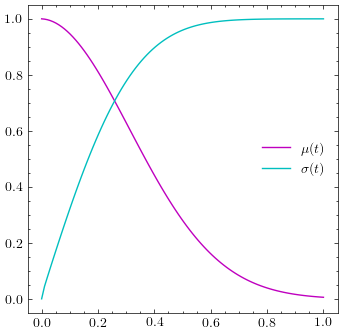

In [3]:
plt.figure(figsize=(4, 4))
t = torch.linspace(epsilon, T, 100)
plt.plot(t, mu(t, "VP").squeeze(), "m", label=r"$\mu(t)$")
plt.plot(t, sigma(t, "VP").squeeze(), "c", label=r"$\sigma(t)$")
plt.legend()

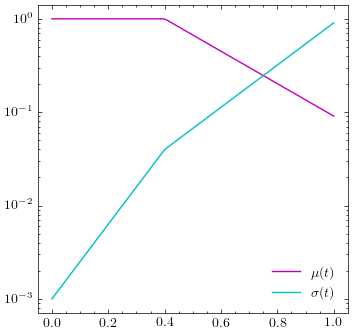

In [4]:
plt.figure(figsize=(4, 4))
t = torch.linspace(epsilon, T, 100)
plt.plot(t, mu(t, "TSVE").squeeze(), "m", label=r"$\mu(t)$")
plt.plot(t, sigma(t, "TSVE").squeeze(), "c", label=r"$\sigma(t)$")
plt.yscale("log")
plt.legend()

For inference, we have
$$
    y = Ax_0 + \eta
$$
At higher temperature, we can write
$$
    y - A(x_0 + z_t) = y - Ax_0 - Az_t = \eta - Az_t
$$
Thus VE results in the simple convolution $\eta - Az_t$ at inference time. We could thus construct a good approximation for the tempered likelihood by convolving it with correlated model noise. 
We can also choose $\sigma(t)$ such that it drowns the noise $\eta$ and s.t. the residuals are dominated by the model noise. 

But with VP we have
$$
     y - A(\mu(t)x_0 + z_t) =  y - A\mu(t)x_0 - Az_t
$$
which do not result in a simple convolution. Instead, at high temperature we get a convolution between the observation and the noise. 

We could however recover a simple convolution if we do
$$
    \mu(t) y - A(\mu(t)x_0 + z_t) =  \mu(t)(y - Ax_0) - Az_t = \mu(t) \eta - Az_t
$$

So, in reality, I should do score matching for SLIC with $-Az_t$, but since diffusion noise is symmetric it really doesn't matter. Also, I now finally have a procedure to temper the likelihood with VP. 

In [5]:
# Make up a likelihood and a prior, and a procedure to anneal them according to the chosen SDE
# Forward model
n = 2 # observation space
m = 1 # model space
# modes = 10 # modes of the prior chosen at random in the prior space
modes = 10
mode_width = 0.5 # If mode width is taken too small, this will bias our approximate SDE. Good check of our approx
coords = torch.randn([modes, m])

# Define a prior (with our SDE as tempering procedure, don't forget to shrink the means by mu(t))
def make_prior(t, sde):
    mean = mu(t, sde) * coords
    scale = (mode_width**2 + sigma(t, sde)**2)**(1/2)
    mixture = tfd.Categorical(torch.ones(modes), validate_args=False)
    component = tfd.Independent(tfd.Normal(mean, scale, validate_args=False), 1) # Uniform diagonal MVN
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

def prior_score(t, x, sde):
    return vmap(grad(lambda t, x: make_prior(t, sde).log_prob(x), argnums=1))(t, x)

def prior_log_prob(t, x, sde):
    return vmap(make_prior(t, sde).log_prob(x))(t, x)

def make_likelihood(t, A, sigma_n, sde, ridge=0):
    # Likelihood with our main approximation (i.e. not the true annealed likelihood)
    # Don't forget to shrink the covariance of the observation accordingly
    Sigma_y = torch.eye(n)  * sigma_n**2 
    cov = mu(t, sde)**2 * Sigma_y +  (A @ A.T + ridge * torch.eye(n)) * sigma(t, sde)**2
    return tfd.MultivariateNormal(torch.zeros(n), covariance_matrix=cov, validate_args=False)

# Use the slic definition
def likelihood_score(y, t, x, A, sigma_n, sde, ridge=0):
    y_hat = left_matmul(A, x)
    # Shrink the observation, see maths above
    residuals = mu(t, sde) * y - y_hat
    slic_score = vmap(grad(lambda t, x: make_likelihood(t, A, sigma_n, sde, ridge).log_prob(x), argnums=1))(t, residuals)
    return - right_matmul(slic_score, A) # don't forget the pesky minus sign!

# a perhaps more intuitive version of the likelihood score
def ref_likelihood_score(y, t, x, A, sigma_n, sde):
    return vmap(grad(lambda t, x: make_likelihood(t, A, sigma_n, sde).log_prob(mu(t, sde)*y - A @ x).squeeze(), argnums=1))(t, x)

# Define a forward model and a likelihood (or a noise distribution). We will keep it gaussian for now
sigma_n = 1e-2
A = torch.randn([n, m])
t = torch.zeros(1) # initialize at zero temperature
x_true = make_prior(t, sde="VP").sample([1])
y_true = left_matmul(A, x_true)

# Make an observation
eta = make_likelihood(t, A, sigma_n, sde="VP").sample([1]) # at 0 temp VP does not affect the distribution
y = y_true + eta

In [6]:
y

tensor([[ 3.5424, -3.2529]])

In [7]:
y_true

tensor([[ 3.5322, -3.2505]])

In [8]:
# some test making sure stuff works
t = torch.zeros(5) #+ epsilon # 0 is always quite unstable with VP
x = make_prior(t[0], "VP").sample([5])
assert torch.allclose(likelihood_score(y, t, x, A, sigma_n, "VP"), ref_likelihood_score(y, t, x, A, sigma_n, "VP"))

# Test inference on our toy framework with VP

At zero temperature, we have Bayes' theorem which gives us the posterior
$$
    p(x \mid y) = \frac{1}{p(y)}\mathcal{N}(y \mid Ax, \Sigma_y) \frac{1}{N}\sum_{i=1}^N\mathcal{N}(x \mid \mu^{(i)}_x, \Sigma_x)
$$
where $N$ is the number of components in our prior mixture. We can simply distribute the likelihood to get
$$
\begin{align}
   p(x \mid y) &= \frac{1}{p(y)} \frac{1}{N}\sum_{i=1}^N \mathcal{N}(y \mid Ax, \Sigma_y)\mathcal{N}(x \mid \mu^{(i)}_x, \Sigma_x) \\
               &= \frac{1}{p(y)} \frac{1}{N}\sum_{i=1}^N q_i \mathcal{N}(x \mid \mu^{(i)}_{x \mid y}, \Sigma_{x \mid y})
\end{align}
$$
where $q_i$ is the weight that we get from renormalising each component of the mixture and $\mu_{x \mid y}$, $\Sigma_{x \mid y}$ have 
the following formulas
$$
\begin{align}
    \Sigma_{x \mid y}^{-1} &= \Sigma_x^{-1} + A \Sigma_y^{-1} A^T \\
    \mu^{(i)}_{x \mid y} &= \Sigma_{x \mid y}(\mu_x^{(i)} + A^T\Sigma_y^{-1}y)
\end{align}    
$$
The formula for the weights $q_i$ depend on the factors left after renormalization. After renormalizing the posteriors, we get the following factor
$$
    q_i \propto  \exp \left(
    -\frac{1}{2}y^T\Sigma_y^{-1}y
        -\frac{1}{2} (\mu_x^{(i)})^T\Sigma_x^{-1}\mu^{(i)}_x - (\Sigma_x^{-1}\mu_x^{(i)} + A^T\Sigma_y^{-1}y)^T\Sigma_{x \mid y}(\Sigma_x^{-1}\mu_x^{(i)} + A^T\Sigma_y^{-1}y)
    \right)
        \sqrt{\frac{|\Sigma_{x \mid y}|}{(2\pi)^{(n)} |\Sigma_y| |\Sigma_{x}|}} 
$$
However, we only need to keep the terms that depend on $i$. The other factors are common to all components of the posterior mixture. We are left with the following weights
$$
    q_i = 
    \exp \left(
        -\frac{1}{2} (\mu_x^{(i)})^T\Sigma_x^{-1}\mu^{(i)}_x - (\Sigma_x^{-1}\mu_x^{(i)} + A^T\Sigma_y^{-1}y)^T\Sigma_{x \mid y}(\Sigma_x^{-1}\mu_x^{(i)} + A^T\Sigma_y^{-1}y)
    \right)
$$

In principle, these factors are NOT impacted by annealing. Only the covariance $\Sigma_{x \mid y}$ and the mean $\mu_{x \mid y}$ are. Although it would be interesting to tes what happens if we anneal the $q_i$ as well. Maybe we recover the approximation.

In [9]:
Sigma_x = torch.eye(m) * mode_width**2
Sigma_y = torch.eye(n) * sigma_n**2
Sigma_x_given_y = (Sigma_x.inverse() + A.T @ Sigma_y.inverse() @ A).inverse()
mu_x_given_y = torch.stack([Sigma_x_given_y @ (coords[i] + A.T @ Sigma_y.inverse() @ y.view(-1)) for i in range(coords.shape[0])])

def log_q(i):
    precision_x = Sigma_x.inverse()
    precision_y = Sigma_y.inverse()
    mu_x = coords[i]
    x_given_y = precision_x @ mu_x + A.T @ precision_y @ y.view(-1)
    return -0.5 * mu_x.T @ precision_x @ mu_x - x_given_y.T @ Sigma_x_given_y @ x_given_y

log_q_i = torch.stack([log_q(i) for i in range(coords.shape[0])])
q = torch.exp(log_q_i - torch.logsumexp(log_q_i, 0))

print(coords[q.argmax()])
q

tensor([1.5670])


/tmp/ipykernel_14369/1589917993.py:11: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3571.)
  return -0.5 * mu_x.T @ precision_x @ mu_x - x_given_y.T @ Sigma_x_given_y @ x_given_y


tensor([3.8786e-13, 1.2752e-07, 0.0000e+00, 1.2168e-07, 5.9481e-14, 1.6379e-18,
        4.3951e-13, 2.4264e-02, 4.5674e-17, 9.6923e-01])

In [10]:
# Construct the reference true posterior, which is the convolution of the product
def make_posterior(t, y, A, sigma_n, sde):
    Sigma_x = torch.eye(m) * mode_width**2
    Sigma_y = torch.eye(n) * sigma_n**2
    Sigma_x_given_y = (Sigma_x.inverse() + A.T @ Sigma_y.inverse() @ A).inverse()
    mu_x_given_y = torch.stack([Sigma_x_given_y @ (coords[i] + A.T @ Sigma_y.inverse() @ y.view(-1)) for i in range(coords.shape[0])])
    
    def log_q(i):
        precision_x = Sigma_x.inverse()
        precision_y = Sigma_y.inverse()
        mu_x = coords[i]
        x_given_y = precision_x @ mu_x + A.T @ precision_y @ y.view(-1)
        return -0.5 * mu_x.T @ precision_x @ mu_x - x_given_y.T @ Sigma_x_given_y @ x_given_y

    log_q_i = torch.stack([log_q(i) for i in range(coords.shape[0])])
    q = torch.exp(log_q_i - torch.logsumexp(log_q_i, 0))

    mean = mu(t, sde) * mu_x_given_y
    cov = mu(t, sde)**2 * Sigma_x_given_y + torch.eye(m) * sigma(t, sde)**2
    mixture = tfd.Categorical(q, validate_args=False)
    component = tfd.MultivariateNormal(mean, covariance_matrix=cov, validate_args=False)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

def posterior_score(t, x, y, A, sigma_n, sde):
    return vmap(grad(lambda t, x: make_posterior(t, y, A, sigma_n, sde).log_prob(x), argnums=1))(t, x)

B = 1000
N = 600 # EM steps
M = 0
snr = 1
leapfrog_steps = 4
mass = 1

# alpha = lambda t: 1 if t[0] < 0. else 100
alpha = 1
def approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge=0):
    return alpha * likelihood_score(y, t, x, A, sigma_n, sde, ridge) + prior_score(t, x, sde)

In [11]:
sde = "VE"
ridge = 1e-6
t = torch.ones([B]) * T
x_ve = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
dt = -T / N
with torch.no_grad():
    for step in tqdm(range(N)):
        score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
        x_ve = backward(t, x_ve, dt, score_fn, sde)
        for _ in range(M):
            epsilon = (snr * sigma(t, sde))**2
            score_fn = lambda x: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
            # x_ve = hmc_step(x_ve, epsilon, score_fn, mass, leapfrog_steps)
            x_ve = ula_step(x_ve, epsilon, score_fn)
        if torch.any(torch.isnan(x_ve)):
            break
        t += dt

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:01<00:00, 337.62it/s]


In [12]:
sde = "VP"
ridge = 1e-6
t = torch.ones([B]) * T
x_vp = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
dt = -T / N
with torch.no_grad():
    for step in tqdm(range(N)):
        score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
        x_vp = backward(t, x_vp, dt, score_fn, sde)
        for _ in range(M):
            epsilon = (snr * sigma(t, sde))**2
            score_fn = lambda x: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
            # x_vp = hmc_step(x_vp, epsilon, score_fn, mass, leapfrog_steps)
            x_vp = ula_step(x_vp, epsilon, score_fn)

        if torch.any(torch.isnan(x_vp)):
            break
        t += dt

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:01<00:00, 317.36it/s]


In [13]:
sde = "TSVE"
ridge = 1e-6
t = torch.ones([B]) * T
x_tsve = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
dt = -T / N
with torch.no_grad():
    for step in tqdm(range(N)):
        score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
        x_tsve = backward(t, x_tsve, dt, score_fn, sde)
        for _ in range(M):
            epsilon = (snr * sigma(t, sde))**2
            score_fn = lambda x: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
            # x_tsve = hmc_step(x_tsve, epsilon, score_fn, mass, leapfrog_steps)
            x_tsve = ula_step(x_tsve, epsilon, score_fn)
        if torch.any(torch.isnan(x_ve)):
            break
        t += dt

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:02<00:00, 280.00it/s]


In [14]:
sde = "VE"
t = torch.ones([B]) * T
x_post = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
dt = -T / N
with torch.no_grad():
    for step in tqdm(range(N)):
        score_fn = lambda t, x, sde: posterior_score(t, x, y, A, sigma_n, sde)
        x_post = backward(t, x_post, dt, score_fn, sde)
        if torch.any(torch.isnan(x_post)):
            break
        t += dt

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:03<00:00, 173.75it/s]


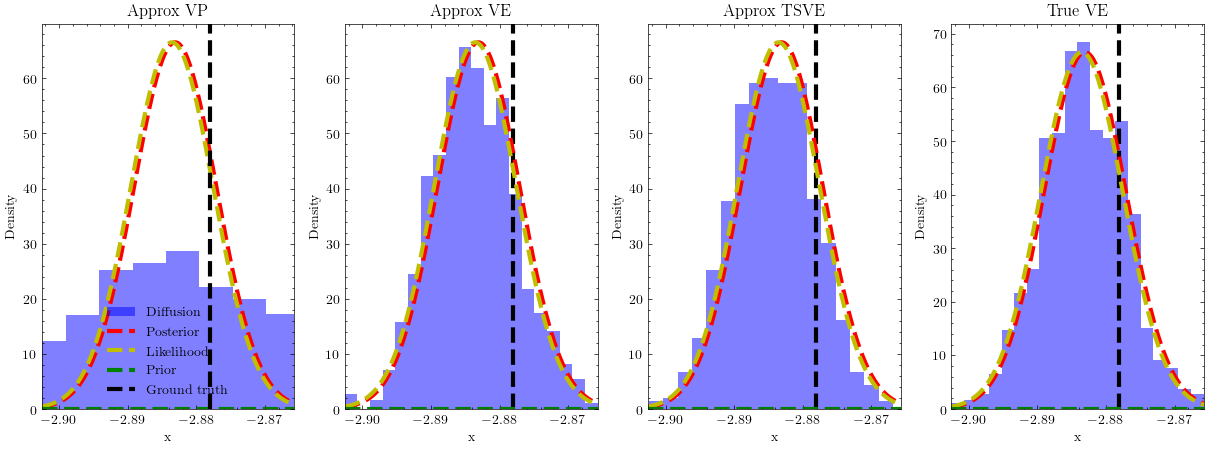

In [15]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5))

xmax = x_ve.max()
xmin = x_ve.min()
x_lin = torch.linspace(xmin, xmax, 200).view(-1, 1).float()
x_like =  torch.linspace(-10, 10, 500).view(-1, 1).float()

post = torch.exp(make_posterior(torch.zeros(1), y, A, sigma_n, "VP").log_prob(x_lin).squeeze())
prior = torch.exp(make_prior(torch.zeros(1), "VP").log_prob(x_lin).squeeze())
likelihood = torch.exp(make_likelihood(torch.zeros(1), A, sigma_n, "VP").log_prob(y - left_matmul(A, x_lin))).squeeze()
likelihood /= likelihood.max() / post.max()

# Posterior is systematically biased if m<<n too large (probably from ridge conditioning)
ax4.set_title("True VE")
ax4.hist(x_post.squeeze(), bins=20, density=True, label="Diffusion", color="b", alpha=0.5)
ax4.axvline(x_true.squeeze(), color="k", ls="--", lw=3)
ax4.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax4.plot(x_lin.squeeze(), likelihood,  "y--", lw=3, label="Likelihood")
ax4.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax4.set_xlabel("x")
ax4.set_xlim(xmin, xmax)
ax4.set_ylabel("Density")

ax3.set_title("Approx TSVE")
ax3.hist(x_tsve.squeeze(), bins=20, density=True, label="Diffusion", color="b", alpha=0.5)
ax3.axvline(x_true.squeeze(), color="k", ls="--", lw=3)
ax3.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax3.plot(x_lin.squeeze(), likelihood,  "y--", lw=3, label="Likelihood")
ax3.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax3.set_xlabel("x")
ax3.set_xlim(xmin, xmax)
ax3.set_ylabel("Density")

ax2.set_title("Approx VE")
ax2.hist(x_ve.squeeze(), bins=20, density=True, label="Diffusion", color="b", alpha=0.5)
ax2.axvline(x_true.squeeze(), color="k", ls="--", lw=3)
ax2.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax2.plot(x_lin.squeeze(), likelihood,  "y--", lw=3, label="Likelihood")
ax2.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax2.set_xlabel("x")
ax2.set_xlim(xmin, xmax)
ax2.set_ylabel("Density")

ax1.set_title("Approx VP")
ax1.hist(x_vp.squeeze(), bins=20, density=True, label="Diffusion", color="b", alpha=0.5)
ax1.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax1.plot(x_lin.squeeze(), likelihood,  "y--", lw=3, label="Likelihood")
ax1.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax1.axvline(x_true.squeeze(), color="k", ls="--", lw=3, label="Ground truth")
ax1.set_xlabel("x")
ax1.set_xlim(xmin, xmax)
ax1.set_ylabel("Density")
ax1.legend()

# How does the guidance factor influence the diffusion?

Can the guidance factor alone calibrate the diffusion? If so why?

From some exploration, the approximate diffusion seems to be better calibrated whenever we increase the importance of the likelihood. Why?


First thing we will do is compare the high temperature distributions to see the impact of the guidance factor there. We will also track the diffusion at those temperature (without corrections)

Note:
Keep in mind that our world model is such that the ground truth is generated by the prior. In the real world, the ground truth might be generated by a different process. We will explore such a case after, since this is the most interesting but also the most tricky case. 

In [16]:
alpha = 1
sde = "VP"
ridge = 1e-6
N = 2000
def approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge):
    return alpha * likelihood_score(y, t, x, A, sigma_n, sde, ridge) + prior_score(t, x, sde)
t = torch.ones([B]) * T
x = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
dt = -T / N

diffusion = []
with torch.no_grad():
    for step in tqdm(range(N)):
        score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde, ridge)
        x = backward(t, x, dt, score_fn, sde)
        diffusion.append(x.numpy().squeeze())
        if torch.any(torch.isnan(x)):
            break
        t += dt

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:06<00:00, 306.12it/s]


/tmp/ipykernel_14369/415595546.py:20: RuntimeWarning: invalid value encountered in divide
  diffusion_post /= diffusion_post.max()


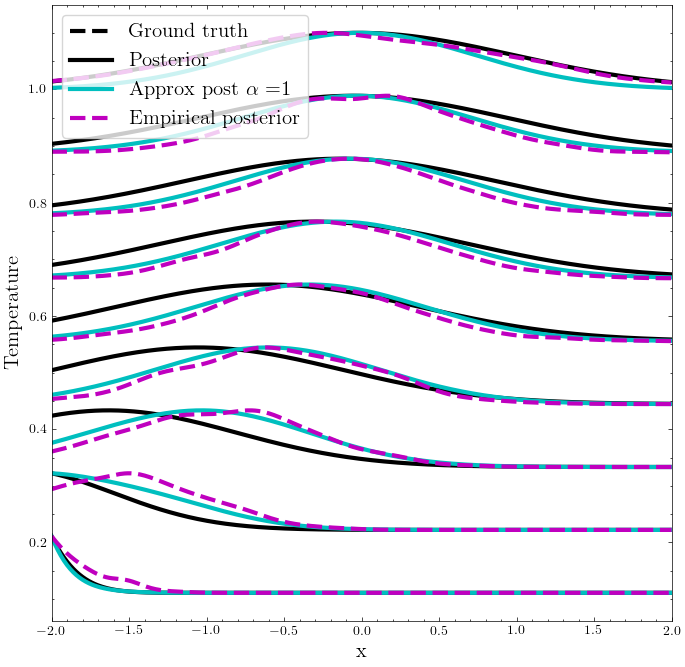

In [17]:
# Check the impact of alpha on VP
xmax = 2 #* sigma(torch.ones(1), sde).item()
xmin = -2 #* sigma(torch.ones(1), sde).item()
x_lin = torch.linspace(xmin, xmax, 400).view(-1, 1).float()

fig, (ax1) = plt.subplots(1, 1, figsize=(8, 8))
Ts = 10
ts = np.linspace(0, T, Ts)
for t in ts:
    post = torch.exp(make_posterior(torch.ones(1)*t, y, A, sigma_n, sde).log_prob(x_lin).squeeze())
    post /= post.max() # renormalize for plotting
    prior = torch.exp(make_prior(torch.ones(1)*t, sde).log_prob(x_lin).squeeze())
    
    likelihood = torch.exp(alpha * make_likelihood(torch.ones(1)*t, A, sigma_n, sde, ridge).log_prob(mu(torch.ones(1)*t, sde)*y - left_matmul(A, x_lin))).squeeze() # Don't forget the to rescale the observation by mu(t)!
    approx_posterior = prior * likelihood
    approx_posterior /= approx_posterior.max() # renormalize for plotting
    
    index = min(int(N * (1-t/T)), N-1)
    diffusion_post = gaussian_kde(diffusion[index])(x_lin.numpy().squeeze())
    diffusion_post /= diffusion_post.max()
    
    l1, = ax1.plot(x_lin.squeeze(), (post + Ts*t/T)/Ts,  "k-", lw=3)
    l2, = ax1.plot(x_lin.squeeze(), (approx_posterior + Ts*t/T)/Ts,  "c-", lw=3)
    l3, = ax1.plot(x_lin.squeeze(), (diffusion_post + Ts*t/T)/Ts,  "m--", lw=3)
gt = ax1.axvline(x_true.squeeze(), color="k", ls="--", lw=3)
lines = [gt, l1, l2, l3]
labels = ["Ground truth", "Posterior", r"Approx post $\alpha=$%d" % alpha, "Empirical posterior"]

ax1.set_xlabel("x", fontsize=15)
# ax1.set_xlim(x_ve.min(), x_ve.max())
ax1.set_xlim(xmin, xmax)
ax1.set_ylabel("Temperature", fontsize=15)
ax1.legend(lines, labels, fontsize=15, frameon=1, loc=2)

# Can we TARP this?

In [501]:
N_posterior = 100
N = 200 # em steps
alphas = [1]#, 5, 10]
sigma_n = 1e-2
ve_posteriors = {key: [] for key in alphas}
vp_posteriors = {key: [] for key in alphas}
A = torch.randn([n, m]) # keep the same A for both experiments


theta = {alpha: [] for alpha in alphas}
ys = {alpha: [] for alpha in alphas}
for alpha in alphas:
    def approximate_posterior_score(t, x, y, A, sigma_n, sde):
        return alpha * likelihood_score(y, t, x, A, sigma_n, sde) + prior_score(t, x, sde)
    for post in tqdm(range(N_posterior)):
        # Create a fake observation
        x_true = make_prior(torch.zeros(1), sde="VP").sample([1])
        theta[alpha].append(x_true)
        y_true = left_matmul(A, x_true)
        eta = make_likelihood(torch.zeros(1), A, sigma_n, sde="VP").sample([1])
        y = y_true + eta
        ys[alpha].append(y)
        
        sde = "VE"
        t = torch.ones([B]) * T
        x_ve = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
        dt = -T / N
        with torch.no_grad():
            for step in range(N):
                score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde)
                x_ve = backward(t, x_ve, dt, score_fn, sde)
                t += dt
                if torch.any(torch.isnan(x_ve)):
                    print("Bad A matrix")
                    break
        if torch.any(torch.isnan(x_ve)):
            break
        ve_posteriors[alpha].append(x_ve.numpy())
        
        sde = "TSVE"
        t = torch.ones([B]) * T
        x_vp = torch.randn([B, m]) * sigma(t, sde) # Start from high temperature
        dt = -T / N
        with torch.no_grad():
            for step in range(N):
                score_fn = lambda t, x, sde: approximate_posterior_score(t, x, y, A, sigma_n, sde)
                x_vp = backward(t, x_vp, dt, score_fn, sde)
                t += dt
        vp_posteriors[alpha].append(x_vp.numpy())
    


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:50<00:00,  1.71s/it]


In [502]:
vp_real_posteriors = []
ve_real_posteriors = []
ys_real = []
theta_real = []
print("Now doing real posterior")
for post in tqdm(range(N_posterior)):
    # Create a fake observation
    x_true = make_prior(torch.zeros(1), sde="VP").sample([1])
    theta_real.append(x_true)
    y_true = left_matmul(A, x_true)
    # Make an observation
    eta = make_likelihood(torch.zeros(1), A, sigma_n, sde="VP").sample([1])
    y = y_true + eta
    ys_real.append(y)

    sde = "VE"
    t = torch.ones([B]) * T
    x_ve = torch.randn([B, m]) * sigma(t, sde)
    dt = -T / N
    with torch.no_grad():
        for step in range(N):
            score_fn = lambda t, x, sde: posterior_score(t, x, y, A, sigma_n, sde)
            x_ve = backward(t, x_ve, dt, score_fn, sde)
            t += dt
            if torch.any(torch.isnan(x_ve)):
                print("Bad A matrix")
                break
    if torch.any(torch.isnan(x_ve)):
        break

    ve_real_posteriors.append(x_ve.numpy())

    sde = "TSVE"
    t = torch.ones([B]) * T
    x_vp = torch.randn([B, m]) * sigma(t, sde)
    dt = -T / N
    with torch.no_grad():
        for step in range(N):
            score_fn = lambda t, x, sde: posterior_score(t, x, y, A, sigma_n, sde)
            x_vp = backward(t, x_vp, dt, score_fn, sde)
            t += dt
    vp_real_posteriors.append(x_vp.numpy())  

Now doing real posterior


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:11<00:00,  3.71s/it]


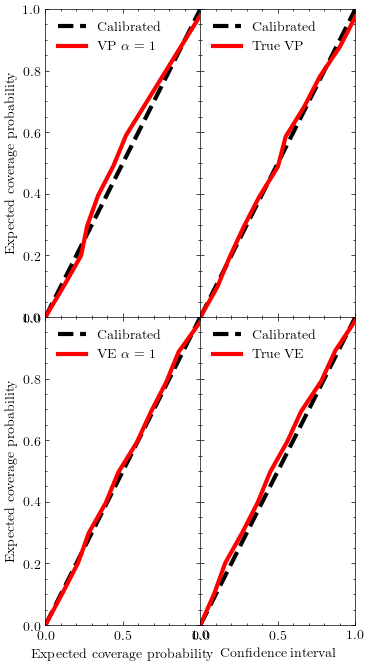

In [503]:
ve_posterior_samples = {alpha: np.stack(ve_posteriors[alpha], 1) for alpha in alphas}
vp_posterior_samples = {alpha: np.stack(vp_posteriors[alpha], 1) for alpha in alphas}
ve_real_posterior_samples = np.stack(ve_real_posteriors, 1)
vp_real_posterior_samples = np.stack(vp_real_posteriors, 1)

theta_samples = {alpha: np.concatenate(theta[alpha]) for alpha in alphas}
theta_real_samples = np.concatenate(theta_real)

csv = {"VE": [], "VP": [], "TVP": [], "TVE": []}
ecps = {"VE": [], "VP": [], "TVP": [], "TVE": []}
for alpha in alphas:
    credibility_values, ecp = get_drp_coverage(ve_posterior_samples[alpha], theta_samples[alpha])
    csv["VE"].append(np.concatenate([np.array([0]), credibility_values]))
    ecps["VE"].append(np.concatenate([np.array([0]), ecp]))
    credibility_values, ecp = get_drp_coverage(vp_posterior_samples[alpha], theta_samples[alpha])
    csv["VP"].append(np.concatenate([np.array([0]), credibility_values]))
    ecps["VP"].append(np.concatenate([np.array([0]), ecp]))
    
credibility_values, ecp = get_drp_coverage(vp_real_posterior_samples, theta_real_samples)
csv["TVP"] = np.concatenate([np.array([0]), credibility_values])
ecps["TVP"] = np.concatenate([np.array([0]), ecp])
credibility_values, ecp = get_drp_coverage(ve_real_posterior_samples, theta_real_samples)
csv["TVE"] = np.concatenate([np.array([0]), credibility_values])
ecps["TVE"] = np.concatenate([np.array([0]), ecp])

fig, axs = plt.subplots(2, len(alphas) + 1, figsize=(len(alphas)*4, 8), sharey=True, sharex=True)
for j in range(len(alphas)):
    axs[0, j].plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
    axs[0, j].plot(csv["VP"][j], ecps["VP"][j], "r-", label=r"VP $\alpha= %.0f$" % alphas[j], lw=3)
    axs[0, j].legend()
    axs[0, j].set_xlim(0, 1)
    axs[0, j].set_ylim(0, 1)

    
    axs[1, j].plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
    axs[1, j].plot(csv["VE"][j], ecps["VE"][j], "r-", label=r"VE $\alpha= %.0f$" % alphas[j], lw=3)
    axs[1, j].legend()
    axs[1, j].set_xlabel(r"Expected coverage probability")
    axs[1, j].set_xlim(0, 1)
    axs[1, j].set_ylim(0, 1)

j = -1
axs[0, j].plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
axs[0, j].plot(csv["TVP"], ecps["TVP"], "r-", label=r"True VP", lw=3)
axs[0, j].legend()
axs[0, j].set_xlim(0, 1)
axs[0, j].set_ylim(0, 1)


axs[1, j].plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
axs[1, j].plot(csv["TVE"], ecps["TVE"], "r-", label=r"True VE", lw=3)
axs[1, j].legend()
axs[1, j].set_xlabel(r"Confidence interval")
axs[1, j].set_xlim(0, 1)
axs[1, j].set_ylim(0, 1)
    
for i in range(2):
    axs[i, 0].set_ylabel(r"Expected coverage probability")
plt.subplots_adjust(hspace=0, wspace=0)

Text(0, 0.5, 'Density')

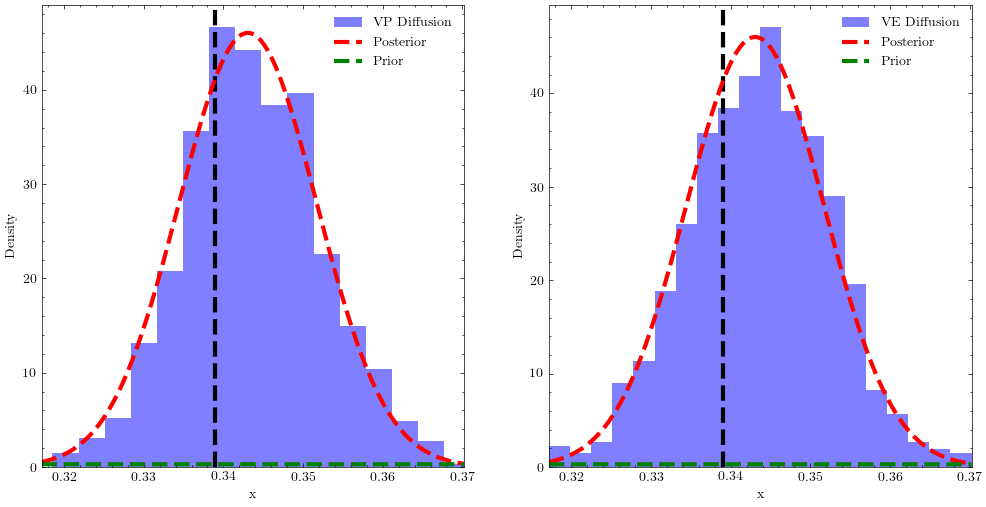

In [543]:
index = np.random.randint(N_posterior)
alpha = alphas[0]

xmax = ve_posterior_samples[alpha][:, index, 0].max()
xmin = ve_posterior_samples[alpha][:, index, 0].min()
x_lin = torch.linspace(xmin, xmax, 200).view(-1, 1).float()

post = torch.exp(make_posterior(torch.zeros(1), ys[alpha][index], A, sigma_n, "VP").log_prob(x_lin).squeeze())
prior = torch.exp(make_prior(torch.zeros(1), "VP").log_prob(x_lin).squeeze())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.hist(vp_posterior_samples[alpha][:, index, 0], bins=20, density=True, label="VP Diffusion", color="b", alpha=0.5)
ax1.axvline(theta_samples[alpha][index, 0], color="k", ls="--", lw=3)
ax1.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax1.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax1.legend()
ax1.set_xlim(xmin, xmax)
ax1.set_xlabel("x")
ax1.set_ylabel("Density")

ax2.hist(ve_posterior_samples[alpha][:, index, 0], bins=20, density=True, label="VE Diffusion", color="b", alpha=0.5)
ax2.axvline(theta_samples[alpha][index, 0], color="k", ls="--", lw=3)
ax2.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax2.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax2.legend()
ax2.set_xlim(xmin, xmax)
ax2.set_xlabel("x")
ax2.set_ylabel("Density")

Text(0, 0.5, 'Density')

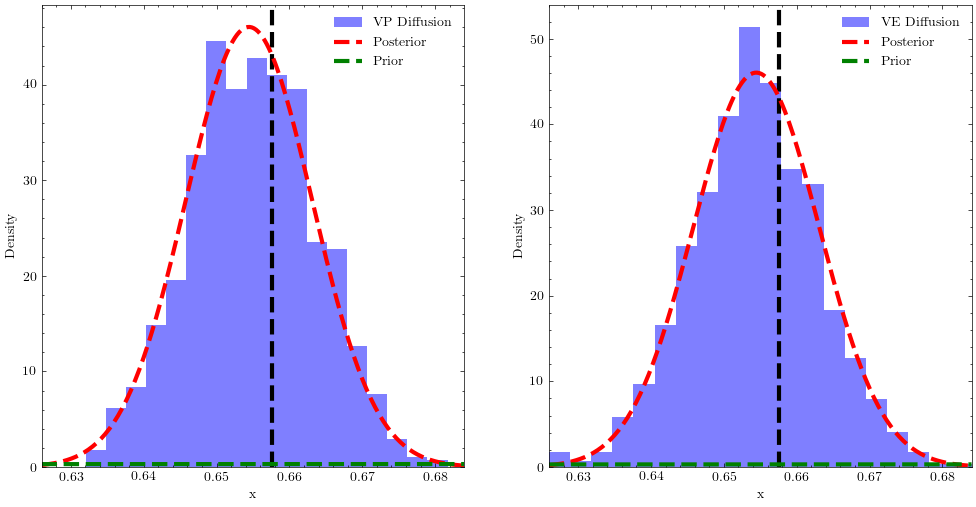

In [509]:
index = np.random.randint(N_posterior)

xmax = ve_real_posterior_samples[:, index, 0].max()
xmin = ve_real_posterior_samples[:, index, 0].min()
x_lin = torch.linspace(xmin, xmax, 200).view(-1, 1).float()
x_like =  torch.linspace(-10, 10, 500).view(-1, 1).float()

post = torch.exp(make_posterior(torch.zeros(1), ys_real[index], A, sigma_n, "VP").log_prob(x_lin).squeeze())
prior = torch.exp(make_prior(torch.zeros(1), "VP").log_prob(x_lin).squeeze())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.hist(vp_real_posterior_samples[:, index, 0], bins=20, density=True, label="VP Diffusion", color="b", alpha=0.5)
ax1.axvline(theta_real_samples[index, 0], color="k", ls="--", lw=3)
ax1.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax1.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax1.legend()
ax1.set_xlim(xmin, xmax)
ax1.set_xlabel("x")
ax1.set_ylabel("Density")

ax2.hist(ve_real_posterior_samples[:, index, 0], bins=20, density=True, label="VE Diffusion", color="b", alpha=0.5)
ax2.axvline(theta_real_samples[index, 0], color="k", ls="--", lw=3)
ax2.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax2.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax2.legend()
ax2.set_xlim(xmin, xmax)
ax2.set_xlabel("x")
ax2.set_ylabel("Density")

# Testing TARP

This can be run on its own

In [174]:
import torch
import torch.distributions as tfd
from torch.func import vmap, grad, vjp
from tqdm import tqdm
from scipy.stats import gaussian_kde
from tarp import get_drp_coverage

n = 2 # observation space
m = 1 # model space
modes = 10 # modes of the prior chosen at random in the prior space
mode_width = 0.5 # If mode width is taken too small, this will bias our approximate SDE. Good check of our approx
coords = torch.randn([modes, m])

# Implementation of the zero temperature distributions
def make_prior():
    mean = coords
    scale = mode_width
    mixture = tfd.Categorical(torch.ones(modes), validate_args=False)
    component = tfd.Independent(tfd.Normal(mean, scale, validate_args=False), 1) # Uniform diagonal MVN
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

def make_likelihood(A, sigma_n):
    cov = torch.eye(n) * sigma_n**2
    return tfd.MultivariateNormal(torch.zeros(n), covariance_matrix=cov, validate_args=False)

def make_posterior(y, A, sigma_n):
    Sigma_x = torch.eye(m) * mode_width**2
    Sigma_y = torch.eye(n) * sigma_n**2
    Sigma_x_given_y = (Sigma_x.inverse() + A.T @ Sigma_y.inverse() @ A).inverse()
    mu_x_given_y = torch.stack([Sigma_x_given_y @ (coords[i] + A.T @ Sigma_y.inverse() @ y.view(-1)) for i in range(coords.shape[0])])
    mean = mu_x_given_y
    cov = Sigma_x_given_y
    mixture = tfd.Categorical(q, validate_args=False)
    component = tfd.MultivariateNormal(mean, covariance_matrix=cov, validate_args=False)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 576.80it/s]


(0.0, 1.0)

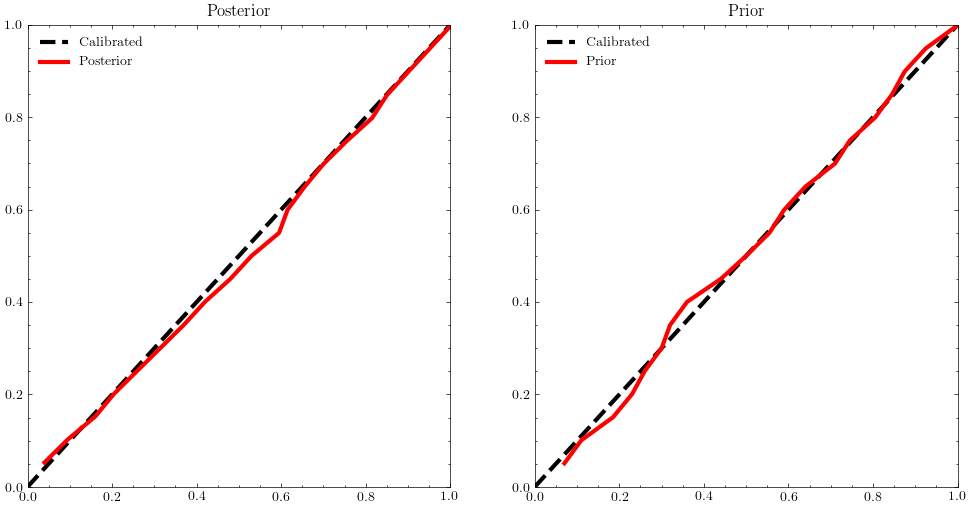

In [175]:
## Compare TARP of prior and posterior
A = torch.ones(n, m)
sigma_n = 0.1
prior = make_prior() # gaussian mixture
likelihood = make_likelihood(A, sigma_n) # gaussian

n_sims = 200
n_samples = 1000

theta = []
ys = []
post_samples = []
prior_samples = []
for _ in tqdm(range(n_sims)):
    theta_star = prior.sample([1]) # ground truth
    z = likelihood.sample([1]) # noise
    y = A @ theta_star.view(m) + z # observation
    posterior = make_posterior(y, A, sigma_n) # gaussian mixture
    samples = posterior.sample([n_samples])
    
    theta.append(theta_star.numpy())
    ys.append(y)
    post_samples.append(samples.numpy())
    prior_samples.append(prior.sample([n_samples]).numpy())
theta = np.concatenate(theta)
post_samples = np.stack(post_samples, 1)
prior_samples = np.stack(prior_samples, 1)

cv_post, ecp_post = get_drp_coverage(post_samples, theta)
cv_prior, ecp_prior = get_drp_coverage(prior_samples, theta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.set_title("Posterior")
ax1.plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
ax1.plot(cv_post, ecp_post, "r-", label="Posterior", lw=3)
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)


ax2.set_title("Prior")
ax2.plot([0, 1], [0, 1], "k--", label="Calibrated", lw=3)
ax2.plot(cv_prior, ecp_prior, "r-", label="Prior", lw=3)
ax2.legend()
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

Text(0, 0.5, 'Density')

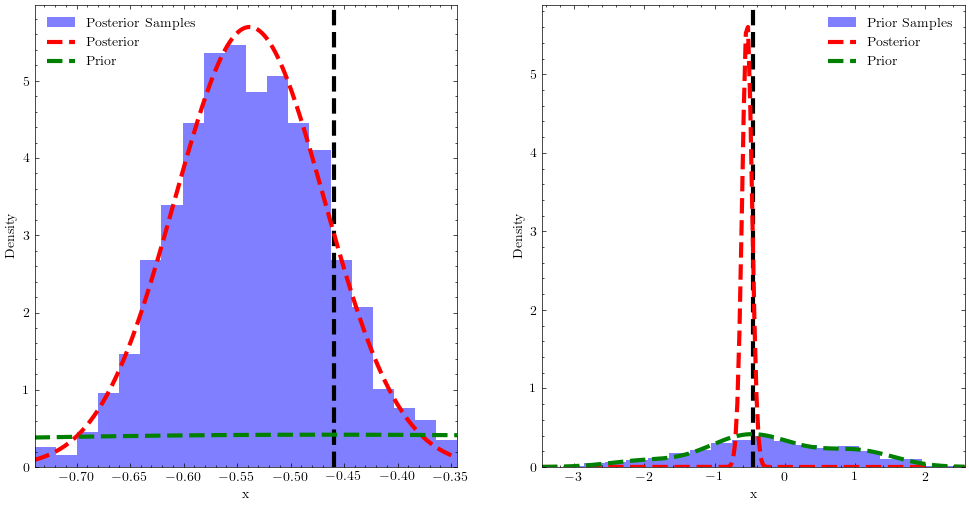

In [177]:
index = np.random.randint(n_sims)
x = post_samples[:, index]

xmax = x.max()
xmin = x.min()
x_lin = torch.linspace(xmin, xmax, 200).view(-1, 1).float()

post = torch.exp(make_posterior(ys[index], A, sigma_n).log_prob(x_lin).squeeze())
prior = torch.exp(make_prior().log_prob(x_lin).squeeze())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.hist(x, bins=20, density=True, label="Posterior Samples", color="b", alpha=0.5)
ax1.axvline(theta[index], color="k", ls="--", lw=3)
ax1.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax1.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax1.legend()
ax1.set_xlim(xmin, xmax)
ax1.set_xlabel("x")
ax1.set_ylabel("Density")

x = prior_samples[:, index]

xmax = x.max()
xmin = x.min()
x_lin = torch.linspace(xmin, xmax, 200).view(-1, 1).float()

post = torch.exp(make_posterior(ys[index], A, sigma_n).log_prob(x_lin).squeeze())
prior = torch.exp(make_prior().log_prob(x_lin).squeeze())

ax2.hist(x, bins=20, density=True, label="Prior Samples", color="b", alpha=0.5)
ax2.axvline(theta[index], color="k", ls="--", lw=3)
ax2.plot(x_lin.squeeze(), post,  "r--", lw=3, label="Posterior")
ax2.plot(x_lin.squeeze(), prior, "g--", lw=3, label="Prior")
ax2.legend()
ax2.set_xlim(xmin, xmax)
ax2.set_xlabel("x")
ax2.set_ylabel("Density")